In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and feature engineering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import umap
# Clustering algorithms
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# Cluster evaluation
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings("ignore")
sns.set()
pd.set_option("display.max_columns", None)
import pickle

## Data Cleaning

Before performing clustering or any machine learning analysis, it is essential to clean and preprocess the data to ensure consistency, accuracy, and meaningful results. In this step, the dataset is prepared by:

- Handling missing values in key financial features such as income and savings.
- Normalizing skewed numeric features, such as monthly expenditure, to reduce the effect of extreme values.
- One-hot encoding categorical features, specifically transaction channel usage, to convert them into numeric format suitable for clustering.
- Cleaning NLP text from customer feedback, including tokenization, removal of stopwords, and punctuation, to prepare it for sentiment analysis and topic modeling.
- Standardizing all numeric features so that they have mean = 0 and standard deviation = 1, ensuring fair contribution of all features during distance-based clustering.

In [2]:
df = pd.read_csv(r"C:\Users\AKANBI BENJAMIN\Documents\finance_customer_behavior_dataset.csv")

In [3]:
df.head()

,Transaction_ID,Customer_ID,Monthly_Expenditure,Income_Level,Spending_Category,Saving_Behavior,Credit_Score,Loan_Status,Loan_Amount,Customer_Feedback,Complaint_Type,Transaction_Channel,Location,Time_Of_Day
0,1,25725,166861.84,Upper-Middle,Savings Deposit,Average,583.0,No Loan,196000.50,Charges are confusing and unclear,NaN,USSD,Ibadan,Morning
1,2,38030,172469.30,Middle,Health,Poor,430.0,No Loan,0.00,Loan process takes too long,Loan Issue,Web,Ibadan,Night
2,3,27730,77825.45,Middle,Rent,Poor,682.0,No Loan,2911313.98,Loan process takes too long,Technical Issue,Web,Port Harcourt,Morning
3,4,71404,130268.89,Low,Education,Good,689.0,No Loan,0.00,Payment failed multiple times,Technical Issue,USSD,Ibadan,Evening
4,5,73206,202452.10,Middle,Education,Good,594.0,No Loan,0.00,The service is excellent,Charges Issue,Mobile App,Lagos,Afternoon


In [4]:
drop_columns = ["Transaction_ID", "Customer_ID"]
df = df.drop(columns=drop_columns)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Monthly_Expenditure  5200 non-null   float64
 1   Income_Level         5200 non-null   object 
 2   Spending_Category    5200 non-null   object 
 3   Saving_Behavior      5196 non-null   object 
 4   Credit_Score         5197 non-null   float64
 5   Loan_Status          5197 non-null   object 
 6   Loan_Amount          5200 non-null   float64
 7   Customer_Feedback    5197 non-null   object 
 8   Complaint_Type       3623 non-null   object 
 9   Transaction_Channel  5198 non-null   object 
 10  Location             5200 non-null   object 
 11  Time_Of_Day          5198 non-null   object 
dtypes: float64(3), object(9)
memory usage: 487.6+ KB


In [6]:
df.columns

Index(['Monthly_Expenditure', 'Income_Level', 'Spending_Category',
       'Saving_Behavior', 'Credit_Score', 'Loan_Status', 'Loan_Amount',
       'Customer_Feedback', 'Complaint_Type', 'Transaction_Channel',
       'Location', 'Time_Of_Day'],
      dtype='object')

In [7]:
df.describe()

,Monthly_Expenditure,Credit_Score,Loan_Amount
count,5200.000000,5197.000000,5.200000e+03
mean,151443.814244,619.595151,1.143014e+06
std,59107.752723,88.838125,1.590018e+06
min,20000.000000,314.000000,0.000000e+00
25%,109850.385000,557.000000,0.000000e+00
50%,151329.515000,621.000000,0.000000e+00
75%,191949.812500,680.000000,2.283251e+06
max,348704.080000,850.000000,4.996312e+06


In [8]:
df.shape

(5200, 12)

In [9]:
df.isna().sum()

Monthly_Expenditure       0
Income_Level              0
Spending_Category         0
Saving_Behavior           4
Credit_Score              3
Loan_Status               3
Loan_Amount               0
Customer_Feedback         3
Complaint_Type         1577
Transaction_Channel       2
Location                  0
Time_Of_Day               2
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df['Saving_Behavior'].fillna(df['Saving_Behavior'].mode()[0], inplace=True)

In [12]:
df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)

In [13]:
df['Loan_Status'].fillna(df['Loan_Status'].mode()[0], inplace=True)

In [14]:
df['Transaction_Channel'].fillna(df['Transaction_Channel'].mode()[0], inplace=True)

In [15]:
df['Time_Of_Day'].fillna(df['Time_Of_Day'].mode()[0], inplace=True)

In [16]:
df['Customer_Feedback'].fillna("No feedback", inplace=True)

In [17]:
df['Complaint_Type'].fillna("No Complaint", inplace=True)

In [18]:
df.isna().sum()

Monthly_Expenditure    0
Income_Level           0
Spending_Category      0
Saving_Behavior        0
Credit_Score           0
Loan_Status            0
Loan_Amount            0
Customer_Feedback      0
Complaint_Type         0
Transaction_Channel    0
Location               0
Time_Of_Day            0
dtype: int64

In [19]:
# Reduce skew
df["Monthly_Expenditure"] = np.log1p(df["Monthly_Expenditure"])

In [20]:
df = pd.get_dummies(df, columns=["Transaction_Channel"], drop_first=True)

In [21]:
# Initialize stopwords
stop_words = set(stopwords.words("english"))

# Function to clean text: lowercase, remove punctuation, tokenize, remove stopwords
def clean_text_basic(text):
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove punctuation (keep only letters and numbers)
    text = re.sub(r"[^\w\s]", "", text)
    
    # 3. Tokenize (split into words)
    tokens = text.split()
    
    # 4. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    return tokens

# Apply function to your customer_feedback column
df["tokens"] = df["Customer_Feedback"].apply(lambda x: clean_text_basic(str(x)))

In [22]:
df.dtypes

Monthly_Expenditure         float64
Income_Level                 object
Spending_Category            object
Saving_Behavior              object
Credit_Score                float64
Loan_Status                  object
Loan_Amount                 float64
Customer_Feedback            object
Complaint_Type               object
Location                     object
Time_Of_Day                  object
Transaction_Channel_POS        bool
Transaction_Channel_USSD       bool
Transaction_Channel_Web        bool
tokens                       object
dtype: object

In [23]:
df.head()

,Monthly_Expenditure,Income_Level,Spending_Category,Saving_Behavior,Credit_Score,Loan_Status,Loan_Amount,Customer_Feedback,Complaint_Type,Location,Time_Of_Day,Transaction_Channel_POS,Transaction_Channel_USSD,Transaction_Channel_Web,tokens
0,12.024927,Upper-Middle,Savings Deposit,Average,583.0,No Loan,196000.50,Charges are confusing and unclear,No Complaint,Ibadan,Morning,False,True,False,"[charges, confusing, unclear]"
1,12.057980,Middle,Health,Poor,430.0,No Loan,0.00,Loan process takes too long,Loan Issue,Ibadan,Night,False,False,True,"[loan, process, takes, long]"
2,11.262237,Middle,Rent,Poor,682.0,No Loan,2911313.98,Loan process takes too long,Technical Issue,Port Harcourt,Morning,False,False,True,"[loan, process, takes, long]"
3,11.777364,Low,Education,Good,689.0,No Loan,0.00,Payment failed multiple times,Technical Issue,Ibadan,Evening,False,True,False,"[payment, failed, multiple, times]"
4,12.218264,Middle,Education,Good,594.0,No Loan,0.00,The service is excellent,Charges Issue,Lagos,Afternoon,False,False,False,"[service, excellent]"


In [24]:
numeric_features = ["Monthly_Expenditure", "Credit_Score", "Loan_Amount"]

scaler = StandardScaler()

# Fit and transform numeric columns
df[numeric_features] = scaler.fit_transform(df[numeric_features])

## Conclusion of Data Cleaning

After completing the data cleaning and preprocessing steps, the dataset is ready for clustering and machine learning tasks. All numeric features are standardized, categorical features are encoded, and text data is cleaned and tokenized for NLP analysis. This ensures that all features contribute appropriately to clustering algorithms and that the resulting customer segments are reliable and interpretable.

## NLP Processing

Natural Language Processing (NLP) is applied to the customer feedback data to extract meaningful insights and generate numeric features suitable for clustering. In this step, the textual data is transformed and analyzed to capture customer sentiment, common complaint themes, and semantic patterns. The main processes include:

- **Lemmatization:** Converting words to their base form (e.g., "running" → "run") to reduce redundancy and improve text representation.
- **Sentiment Analysis:** Assigning a sentiment score to each feedback (positive, negative, or neutral) using tools such as VADER, spaCy, or transformer-based models.
- **Topic Modeling:** Identifying recurring themes or topics in customer feedback using techniques such as LDA or BERTopic.
- **Generating Embeddings:** Converting text into numeric vectors using TF-IDF or sentence transformer embeddings, which can then be combined with other features for clustering.

In [25]:
#Initialize NLP Tools
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
sia = SentimentIntensityAnalyzer()

In [26]:
# Clean and Lemmatize Text
def clean_and_lemmatize(text):
    # Lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)
    
    # Tokenize
    tokens = text.split()
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join back into string
    return " ".join(tokens)

# Apply to customer_feedback column
df["clean_feedback"] = df["Customer_Feedback"].apply(lambda x: clean_and_lemmatize(str(x)))

In [27]:
# Sentiment Analysis (VADER)
# Get sentiment score for each feedback
df["sentiment_score"] = df["clean_feedback"].apply(lambda x: sia.polarity_scores(x)["compound"])

In [28]:
# Topic Modeling using LDA
# Convert text to document-term matrix
vectorizer = CountVectorizer(max_df=0.9, min_df=2)  # ignores very common and very rare words
X_text = vectorizer.fit_transform(df["clean_feedback"])

# Fit LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=42)  # 5 topics
lda_topics = lda.fit_transform(X_text)

# Add topic probabilities as new columns
for i in range(lda_topics.shape[1]):
    df[f"topic_{i}"] = lda_topics[:, i]

In [29]:
# TF-IDF Embeddings
tfidf = TfidfVectorizer(max_features=100)  # limit features for simplicity
tfidf_matrix = tfidf.fit_transform(df["clean_feedback"]).toarray()

# Add TF-IDF features to dataframe
tfidf_cols = [f"tfidf_{i}" for i in range(tfidf_matrix.shape[1])]
df_tfidf = pd.DataFrame(tfidf_matrix, columns=tfidf_cols)
df = pd.concat([df.reset_index(drop=True), df_tfidf.reset_index(drop=True)], axis=1)

In [30]:
df.head()

,Monthly_Expenditure,Income_Level,Spending_Category,Saving_Behavior,Credit_Score,Loan_Status,Loan_Amount,Customer_Feedback,Complaint_Type,Location,Time_Of_Day,Transaction_Channel_POS,Transaction_Channel_USSD,Transaction_Channel_Web,tokens,clean_feedback,sentiment_score,topic_0,topic_1,topic_2,topic_3,topic_4,tfidf_0,tfidf_1,tfidf_2,tfidf_3,tfidf_4,tfidf_5,tfidf_6,tfidf_7,tfidf_8,tfidf_9,tfidf_10,tfidf_11,tfidf_12,tfidf_13,tfidf_14,tfidf_15,tfidf_16,tfidf_17,tfidf_18,tfidf_19,tfidf_20,tfidf_21,tfidf_22,tfidf_23,tfidf_24,tfidf_25,tfidf_26,tfidf_27,tfidf_28,tfidf_29,tfidf_30,tfidf_31,tfidf_32,tfidf_33,tfidf_34
0,0.397819,Upper-Middle,Savings Deposit,Average,-0.412098,No Loan,-0.595657,Charges are confusing and unclear,No Complaint,Ibadan,Morning,False,True,False,"[charges, confusing, unclear]",charge confusing unclear,-0.4404,0.050000,0.050000,0.800000,0.050000,0.050000,0.0,0.0,0.615475,0.492323,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.615475,0.0
1,0.464730,Middle,Health,Poor,-2.134995,No Loan,-0.718938,Loan process takes too long,Loan Issue,Ibadan,Night,False,False,True,"[loan, process, takes, long]",loan process take long,0.0000,0.040000,0.840000,0.040000,0.040000,0.040000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.424781,0.522673,0.000000,0.0,0.0,0.00000,0.0,0.522673,0.0,0.0,0.000000,0.0,0.0,0.0,0.522673,0.000000,0.0,0.000000,0.0
2,-1.146152,Middle,Rent,Poor,0.702717,No Loan,1.112232,Loan process takes too long,Technical Issue,Port Harcourt,Morning,False,False,True,"[loan, process, takes, long]",loan process take long,0.0000,0.040000,0.840000,0.040000,0.040000,0.040000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.424781,0.522673,0.000000,0.0,0.0,0.00000,0.0,0.522673,0.0,0.0,0.000000,0.0,0.0,0.0,0.522673,0.000000,0.0,0.000000,0.0
3,-0.103343,Low,Education,Good,0.781542,No Loan,-0.718938,Payment failed multiple times,Technical Issue,Ibadan,Evening,False,True,False,"[payment, failed, multiple, times]",payment failed multiple time,-0.5106,0.040717,0.040000,0.839283,0.040000,0.040000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.525204,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.525204,0.0,0.0,0.41531,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.525204,0.0,0.000000,0.0
4,0.789203,Middle,Education,Good,-0.288230,No Loan,-0.718938,The service is excellent,Charges Issue,Lagos,Afternoon,False,False,False,"[service, excellent]",service excellent,0.5719,0.066667,0.066667,0.066667,0.733333,0.066667,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.785014,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.619479,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0


## Conclusion of NLP Processing

After NLP processing, the customer feedback data has been transformed into structured numeric features suitable for clustering. Each feedback entry now has:

- **Lemmatized text**, reducing redundancy and improving consistency.
- **Sentiment scores**, capturing the emotional tone of each customer.
- **Topic probabilities**, representing recurring themes in the feedback.
- **TF-IDF embeddings**, encoding the importance of words in numeric form.

These NLP-derived features can now be combined with other numeric and categorical features to create a complete dataset for clustering, enabling the identification of meaningful customer segments.

## Feature Engineering

Feature Engineering aims to transform and optimize the dataset to improve clustering performance and computational efficiency. In this step, we focus on reducing the dimensionality of numeric and NLP features, while retaining the most relevant information. The main processes include:

- **PCA on Numeric Data:** Compress correlated numeric features into principal components that retain maximum variance.
- **UMAP/PCA on Text Embeddings:** Reduce high-dimensional NLP embeddings or TF-IDF vectors into lower-dimensional representations while preserving semantic relationships.
- **Merging Structured and NLP Features:** Combine the reduced numeric and text features with categorical and binary features into a unified matrix for clustering.

In [31]:
# Identify feature groups
# Numeric features (already standardized)
numeric_features = ["Monthly_Expenditure", "Credit_Score", "Loan_Amount", "sentiment_score"]

# Categorical features to encode
categorical_features = ["Income_Level", "Spending_Category", "Saving_Behavior", "Loan_Status",
                        "Complaint_Type", "Location", "Time_Of_Day"]

# Binary features
binary_features = ["Transaction_Channel_POS", "Transaction_Channel_USSD", "Transaction_Channel_Web"]

# NLP features
topic_features = ["topic_0", "topic_1", "topic_2", "topic_3", "topic_4"]
tfidf_features = [col for col in df.columns if "tfidf_" in col]

In [32]:
# Dimensionality reduction
# PCA on numeric features
pca_numeric = PCA(n_components=2, random_state=42)
numeric_reduced = pca_numeric.fit_transform(df[numeric_features])
numeric_reduced_df = pd.DataFrame(numeric_reduced, columns=["num_PC1", "num_PC2"])

#PCA on NLP features (topics + TF-IDF)
nlp_features = topic_features + tfidf_features
pca_nlp = PCA(n_components=10, random_state=42)
nlp_reduced = pca_nlp.fit_transform(df[nlp_features])
nlp_reduced_df = pd.DataFrame(nlp_reduced, columns=[f"nlp_PC{i}" for i in range(nlp_reduced.shape[1])])

In [33]:
# Encode categorical features
encoder = OneHotEncoder(sparse_output=False, drop="first")

encoded_cat = encoder.fit_transform(df[categorical_features])
encoded_cat_df = pd.DataFrame(
    encoded_cat, 
    columns=encoder.get_feature_names_out(categorical_features)
)

In [34]:
# Combine all features
X_final = pd.concat([numeric_reduced_df.reset_index(drop=True),
                     nlp_reduced_df.reset_index(drop=True),
                     encoded_cat_df.reset_index(drop=True),
                     df[binary_features].reset_index(drop=True)], axis=1)

print("Final feature matrix shape:", X_final.shape)

Final feature matrix shape: (5200, 44)


In [35]:
# Check the first few rows of the final feature matrix
# This helps verify that numeric, NLP, categorical, and binary features are correctly merged
X_final.head()

,num_PC1,num_PC2,nlp_PC0,nlp_PC1,nlp_PC2,nlp_PC3,nlp_PC4,nlp_PC5,nlp_PC6,nlp_PC7,nlp_PC8,nlp_PC9,Income_Level_Low,Income_Level_Lower-Middle,Income_Level_Middle,Income_Level_Upper-Middle,Spending_Category_Entertainment,Spending_Category_Groceries,Spending_Category_Health,Spending_Category_Online Shopping,Spending_Category_Rent,Spending_Category_Savings Deposit,Spending_Category_Transport,Spending_Category_Utilities,Saving_Behavior_Good,Saving_Behavior_Poor,Loan_Status_Default Risk,Loan_Status_No Loan,Complaint_Type_General Feedback,Complaint_Type_Loan Issue,Complaint_Type_No Complaint,Complaint_Type_Technical Issue,Location_Enugu,Location_Ibadan,Location_Kaduna,Location_Kano,Location_Lagos,Location_Port Harcourt,Time_Of_Day_Evening,Time_Of_Day_Morning,Time_Of_Day_Night,Transaction_Channel_POS,Transaction_Channel_USSD,Transaction_Channel_Web
0,-0.672610,-0.415267,0.772728,-0.393254,-0.122825,-0.261247,0.036274,-0.328002,0.013210,-0.012027,-0.004565,-0.004161,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,False,True,False
1,-2.012464,-0.799694,-0.052705,0.286378,0.991369,-0.139198,-0.015572,0.012037,0.003654,-0.014013,-0.596214,-0.005705,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False,False,True
2,1.471037,0.566017,-0.052705,0.286378,0.991369,-0.139198,-0.015572,0.012037,0.003654,-0.014013,-0.596214,-0.005705,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,False,False,True
3,0.510137,-0.536955,0.673423,-0.333023,-0.100050,0.099462,-0.134504,0.877181,-0.025658,0.002145,-0.000492,-0.006841,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,False,True,False
4,-0.860893,-0.308829,-0.615534,-0.481897,-0.115768,-0.079218,-0.348677,-0.041929,-0.005789,0.001929,0.003636,0.680202,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,False,False,False


## Conclusion of Feature Engineering

After applying PCA to numeric and NLP features and one-hot encoding categorical features, all relevant information has been transformed into a unified, lower-dimensional numeric matrix. 

This final feature set, `X_final`, combines:
- Compressed numeric components
- Reduced NLP embeddings (topics + TF-IDF)
- One-hot encoded categorical variables
- Binary features

`X_final` is now ready for clustering algorithms, ensuring computational efficiency while retaining meaningful patterns in the data.

## Unsupervised Modeling

In this step, we apply unsupervised learning algorithms to identify patterns and group similar customers based on their behavior, spending, and sentiment. The goal is to uncover meaningful customer segments without using any labeled target variable. 

The main models to evaluate include:

- **K-Means Clustering:** A baseline algorithm that partitions customers into K clusters based on feature similarity.
- **Hierarchical Clustering:** Builds a tree of clusters to explore nested customer groupings.
- **Gaussian Mixture Models (GMM):** Probabilistic clustering that allows overlapping clusters and soft assignments.
- **DBSCAN:** Detects clusters of arbitrary shape and identifies outliers, useful for spotting behavioral anomalies.

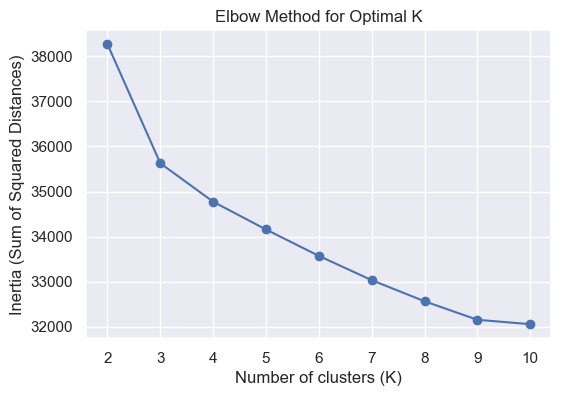

In [36]:
# Elbow Method to determine optimal K
inertia_list = []
K_range = range(2, 11)  # testing 2 to 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_final)
    inertia_list.append(kmeans.inertia_)

# Plot the elbow
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia_list, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.show()

In [37]:
inertia_list

[38270.4228748763,
 35627.17870717395,
 34773.531474520314,
 34157.29485070099,
 33571.06787597013,
 33032.37450388132,
 32563.665788671893,
 32152.89043391556,
 32055.33432660478]

In [38]:
# Fit KMeans with chosen K
optimal_k = 3  # set based on elbow plot
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_final)

# Add cluster labels to X_final for analysis
X_final["Cluster"] = cluster_labels

In [39]:
# Inspect cluster sizes
print(X_final["Cluster"].value_counts())

Cluster
0    2434
1    1442
2    1324
Name: count, dtype: int64


In [40]:

# Examine cluster centroids
# Centroids in feature space; useful for interpretation
centroids = pd.DataFrame(kmeans_final.cluster_centers_, columns=X_final.columns[:-1])
centroids

,num_PC1,num_PC2,nlp_PC0,nlp_PC1,nlp_PC2,nlp_PC3,nlp_PC4,nlp_PC5,nlp_PC6,nlp_PC7,nlp_PC8,nlp_PC9,Income_Level_Low,Income_Level_Lower-Middle,Income_Level_Middle,Income_Level_Upper-Middle,Spending_Category_Entertainment,Spending_Category_Groceries,Spending_Category_Health,Spending_Category_Online Shopping,Spending_Category_Rent,Spending_Category_Savings Deposit,Spending_Category_Transport,Spending_Category_Utilities,Saving_Behavior_Good,Saving_Behavior_Poor,Loan_Status_Default Risk,Loan_Status_No Loan,Complaint_Type_General Feedback,Complaint_Type_Loan Issue,Complaint_Type_No Complaint,Complaint_Type_Technical Issue,Location_Enugu,Location_Ibadan,Location_Kaduna,Location_Kano,Location_Lagos,Location_Port Harcourt,Time_Of_Day_Evening,Time_Of_Day_Morning,Time_Of_Day_Night,Transaction_Channel_POS,Transaction_Channel_USSD,Transaction_Channel_Web
0,-0.728049,-0.369799,-0.006303,0.007656,-0.016307,-0.013156,-0.001822,-0.007355,0.000113,-0.005093,-0.004350,-0.003231,0.248766,0.280428,0.261513,0.154605,0.107730,0.117187,0.105263,0.104030,0.106086,0.103207,0.125000,0.128701,0.288651,0.301398,0.108141,0.551809,0.256579,0.092928,0.293174,0.206003,0.132401,0.153372,0.154605,0.151316,0.128701,0.139391,0.262747,0.238487,0.262747,0.244655,0.253701,0.245477
1,0.993735,-0.682250,0.031629,-0.016641,0.019608,0.012283,0.000529,0.009352,-0.000028,-0.003856,0.000908,0.006487,0.245152,0.286704,0.267313,0.142659,0.114266,0.112188,0.112188,0.107341,0.126039,0.110803,0.115651,0.108726,0.308172,0.306094,0.108726,0.544321,0.243767,0.108726,0.310249,0.190443,0.150970,0.121884,0.128809,0.154432,0.148892,0.147507,0.228532,0.266620,0.254848,0.263850,0.256925,0.226454
2,0.253522,1.423354,-0.022919,0.004087,0.008568,0.010769,0.002771,0.003310,-0.000177,0.013561,0.007001,-0.001139,0.271148,0.307402,0.229607,0.144260,0.111027,0.131420,0.110272,0.100453,0.108006,0.101964,0.107251,0.122356,0.301360,0.295317,0.108006,0.533988,0.237915,0.095166,0.314199,0.205438,0.135196,0.172205,0.134441,0.141239,0.141994,0.123867,0.249245,0.256798,0.271903,0.246979,0.256798,0.246979


In [41]:
# Fit Agglomerative Hierarchical Clustering
hier_clust = AgglomerativeClustering(n_clusters=3, linkage="ward")  # same K as KMeans
hier_labels = hier_clust.fit_predict(X_final.drop(columns="Cluster"))  # drop KMeans cluster column

# Add labels to dataframe
X_final["Hier_Cluster"] = hier_labels

# Inspect cluster sizes
print(X_final["Hier_Cluster"].value_counts())

Hier_Cluster
0    2935
1    1229
2    1036
Name: count, dtype: int64


In [42]:
# Fit GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_final.drop(columns=["Cluster", "Hier_Cluster"]))

# Add labels to dataframe
X_final["GMM_Cluster"] = gmm_labels

# Inspect cluster sizes
print(X_final["GMM_Cluster"].value_counts())

GMM_Cluster
1    3023
0    1677
2     500
Name: count, dtype: int64


In [43]:
# Fit GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_final.drop(columns=["Cluster", "Hier_Cluster"]))

# Add labels to dataframe
X_final["GMM_Cluster"] = gmm_labels

# Inspect cluster sizes
print(X_final["GMM_Cluster"].value_counts())

GMM_Cluster
1    3023
0    1677
2     500
Name: count, dtype: int64


In [44]:
# Select numeric PCA + NLP UMAP features
reduced_features = ["num_PC1", "num_PC2"] + [f"nlp_PC{i}" for i in range(10)]
X_reduced = X_final[reduced_features].values

# Scale reduced features (important for distance-based DBSCAN)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

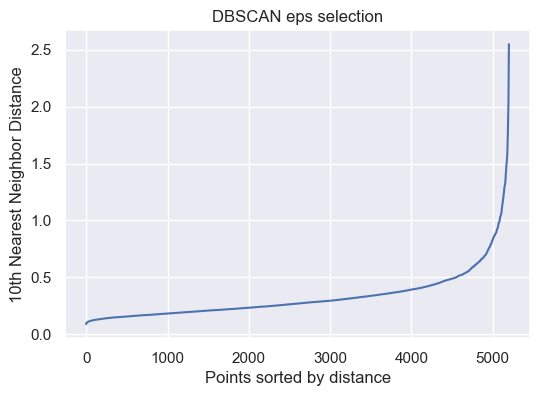

In [45]:
# Use min_samples = 10
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances of 10th nearest neighbor
distances = np.sort(distances[:, -1])

# Plot to find the "knee" (ideal eps)
plt.figure(figsize=(6,4))
plt.plot(distances)
plt.ylabel("10th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.title("DBSCAN eps selection")
plt.show()

In [46]:
# Using eps = 0.65 from k-distance plot
dbscan = DBSCAN(eps=0.65, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)

# Add DBSCAN labels to dataframe
X_final["DBSCAN_Cluster"] = db_labels

# Inspect cluster sizes (note: -1 = outliers/anomalies)
print(X_final["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0     871
 9     442
 8     439
 1     438
 7     438
 6     425
 4     407
 10    402
 2     399
 5     392
 3     390
-1     157
Name: count, dtype: int64


In [47]:
def evaluate_clustering(X, labels, model_name="Cluster"):
    # Silhouette Score: -1 (bad) → 1 (good)
    sil_score = silhouette_score(X, labels)
    
    # Calinski-Harabasz: higher is better
    ch_score = calinski_harabasz_score(X, labels)
    
    # Davies-Bouldin: lower is better
    db_score = davies_bouldin_score(X, labels)
    
    print(f"=== {model_name} ===")
    print(f"Silhouette Score       : {sil_score:.4f}")
    print(f"Calinski-Harabasz Score: {ch_score:.4f}")
    print(f"Davies-Bouldin Score   : {db_score:.4f}\n")
    
    return sil_score, ch_score, db_score

In [48]:
# Features used for clustering (scaled/reduced)
cluster_features = X_final.drop(columns=["Cluster", "Hier_Cluster", "GMM_Cluster", "DBSCAN_Cluster"])

# KMeans
evaluate_clustering(cluster_features, X_final["Cluster"], model_name="KMeans")

# Hierarchical
evaluate_clustering(cluster_features, X_final["Hier_Cluster"], model_name="Hierarchical")

# Gaussian Mixture
evaluate_clustering(cluster_features, X_final["GMM_Cluster"], model_name="GMM")

# DBSCAN (exclude outliers for metrics if needed)
db_labels = X_final["DBSCAN_Cluster"]
mask = db_labels != -1
evaluate_clustering(cluster_features[mask], db_labels[mask], model_name="DBSCAN (core points)")

=== KMeans ===
Silhouette Score       : 0.0853
Calinski-Harabasz Score: 474.4942
Davies-Bouldin Score   : 2.8310

=== Hierarchical ===
Silhouette Score       : 0.0604
Calinski-Harabasz Score: 341.4366
Davies-Bouldin Score   : 3.3740

=== GMM ===
Silhouette Score       : 0.0145
Calinski-Harabasz Score: 73.9896
Davies-Bouldin Score   : 7.2701

=== DBSCAN (core points) ===
Silhouette Score       : 0.0653
Calinski-Harabasz Score: 100.0478
Davies-Bouldin Score   : 3.7403



(0.06533921621993896, 100.04780969879901, 3.740348971648857)

## Unsupervised Modeling — Conclusion

In this phase, multiple clustering algorithms were applied to the unified dataset, which combined numeric, categorical, and NLP-derived features. Key takeaways:

- **KMeans (K=3)** provided the most coherent clustering based on evaluation metrics (Silhouette, Calinski-Harabasz, Davies-Bouldin), making it suitable as the **baseline clustering model**.

- **Hierarchical Clustering** and **Gaussian Mixture Models (GMM)** produced less distinct clusters in this feature space.

- **DBSCAN** was effective at identifying **behavioral anomalies/outliers**, detecting a subset of customers with unusual patterns, though its overall cluster cohesion was lower.

- **Dimensionality reduction** (PCA for numeric features, UMAP for NLP embeddings) and **feature scaling** were critical to improve clustering performance and make distance-based algorithms meaningful.

This phase establishes a robust foundation for **customer segmentation** while highlighting potential outliers for further investigation.

## Cluster Validation & Interpretation

In this session, we focus on **analyzing and interpreting the clusters** obtained from the unsupervised modeling phase. The objective is to transform the raw cluster assignments into **actionable customer personas** by understanding the dominant characteristics of each cluster.

### Key Activities

- **Examine cluster centroids or feature averages** to identify patterns in:  
  - Spending  
  - Digital payment behavior  
  - Savings habits  
  - Sentiment  

- **Compare cluster statistics** against the overall population to highlight distinctive behaviors.

- **Assign descriptive names** to clusters to summarize behavioral insights, such as:  
  - High Spenders with Positive Sentiment  
  - Low Income, Irregular Savings, High Complaints  
  - Digital-First, Mobile Money Heavy Users  
  - Stable Earners with Consistent Savings  
  - Cash-Based, Low Digital Adoption Users  

This step bridges the gap between **technical clustering outputs** and **business-relevant customer insights**, enabling targeted strategies and personalized interventions.

In [49]:
# Separate features used for clustering
cluster_features = X_final.drop(columns=["Cluster", "Hier_Cluster", "GMM_Cluster", "DBSCAN_Cluster"])

# Compute cluster centroids (mean of each feature per cluster)
centroids = X_final.groupby("Cluster")[cluster_features.columns].mean()
centroids

,num_PC1,num_PC2,nlp_PC0,nlp_PC1,nlp_PC2,nlp_PC3,nlp_PC4,nlp_PC5,nlp_PC6,nlp_PC7,nlp_PC8,nlp_PC9,Income_Level_Low,Income_Level_Lower-Middle,Income_Level_Middle,Income_Level_Upper-Middle,Spending_Category_Entertainment,Spending_Category_Groceries,Spending_Category_Health,Spending_Category_Online Shopping,Spending_Category_Rent,Spending_Category_Savings Deposit,Spending_Category_Transport,Spending_Category_Utilities,Saving_Behavior_Good,Saving_Behavior_Poor,Loan_Status_Default Risk,Loan_Status_No Loan,Complaint_Type_General Feedback,Complaint_Type_Loan Issue,Complaint_Type_No Complaint,Complaint_Type_Technical Issue,Location_Enugu,Location_Ibadan,Location_Kaduna,Location_Kano,Location_Lagos,Location_Port Harcourt,Time_Of_Day_Evening,Time_Of_Day_Morning,Time_Of_Day_Night,Transaction_Channel_POS,Transaction_Channel_USSD,Transaction_Channel_Web
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.727405,-0.370267,-0.005946,0.007491,-0.016333,-0.012750,-0.001804,-0.007566,0.000124,-0.005103,-0.004351,-0.003237,0.248562,0.280197,0.261298,0.154889,0.107642,0.117502,0.105177,0.104355,0.105998,0.103122,0.124897,0.128595,0.289236,0.301150,0.108053,0.551356,0.256779,0.093262,0.292933,0.205834,0.132293,0.153246,0.154889,0.151191,0.128595,0.139277,0.262942,0.238291,0.262531,0.244454,0.253492,0.245686
1,0.995035,-0.681893,0.031079,-0.016397,0.019702,0.011633,0.000500,0.009731,-0.000046,-0.003837,0.000916,0.006509,0.245492,0.287101,0.267684,0.142164,0.114424,0.111650,0.112344,0.106796,0.126214,0.110957,0.115811,0.108877,0.307212,0.306519,0.108877,0.545076,0.243412,0.108183,0.310680,0.190707,0.151179,0.122053,0.128294,0.154646,0.149098,0.147712,0.228155,0.266990,0.255201,0.264216,0.257282,0.226075
2,0.253522,1.423354,-0.022919,0.004087,0.008568,0.010769,0.002771,0.003310,-0.000177,0.013561,0.007001,-0.001139,0.271148,0.307402,0.229607,0.144260,0.111027,0.131420,0.110272,0.100453,0.108006,0.101964,0.107251,0.122356,0.301360,0.295317,0.108006,0.533988,0.237915,0.095166,0.314199,0.205438,0.135196,0.172205,0.134441,0.141239,0.141994,0.123867,0.249245,0.256798,0.271903,0.246979,0.256798,0.246979


In [50]:
# Compare cluster centroids to overall population mean
population_mean = cluster_features.mean()

# Highlight features where cluster deviates significantly from population mean
deviation = centroids - population_mean
deviation

,num_PC1,num_PC2,nlp_PC0,nlp_PC1,nlp_PC2,nlp_PC3,nlp_PC4,nlp_PC5,nlp_PC6,nlp_PC7,nlp_PC8,nlp_PC9,Income_Level_Low,Income_Level_Lower-Middle,Income_Level_Middle,Income_Level_Upper-Middle,Spending_Category_Entertainment,Spending_Category_Groceries,Spending_Category_Health,Spending_Category_Online Shopping,Spending_Category_Rent,Spending_Category_Savings Deposit,Spending_Category_Transport,Spending_Category_Utilities,Saving_Behavior_Good,Saving_Behavior_Poor,Loan_Status_Default Risk,Loan_Status_No Loan,Complaint_Type_General Feedback,Complaint_Type_Loan Issue,Complaint_Type_No Complaint,Complaint_Type_Technical Issue,Location_Enugu,Location_Ibadan,Location_Kaduna,Location_Kano,Location_Lagos,Location_Port Harcourt,Time_Of_Day_Evening,Time_Of_Day_Morning,Time_Of_Day_Night,Transaction_Channel_POS,Transaction_Channel_USSD,Transaction_Channel_Web
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.727405,-0.370267,-0.005946,0.007491,-0.016333,-0.012750,-0.001804,-0.007566,0.000124,-0.005103,-0.004351,-0.003237,-0.004900,-0.008841,0.006298,0.006235,-0.002743,-0.001921,-0.003285,0.000317,-0.006117,-0.001878,0.007013,0.007056,-0.008072,-0.000003,-0.000217,0.006163,0.008510,-0.004622,-0.010336,0.004296,-0.005977,0.003823,0.012581,0.001576,-0.009097,0.001585,0.013134,-0.012671,-0.000354,-0.006123,-0.001892,0.005109
1,0.995035,-0.681893,0.031079,-0.016397,0.019702,0.011633,0.000500,0.009731,-0.000046,-0.003837,0.000916,0.006509,-0.007969,-0.001937,0.012684,-0.006490,0.004040,-0.007773,0.003882,0.002758,0.014098,0.005957,-0.002073,-0.012662,0.009905,0.005365,0.000607,-0.000116,-0.004857,0.010298,0.007410,-0.010831,0.012910,-0.027370,-0.014014,0.005031,0.011406,0.010019,-0.021652,0.016029,-0.007684,0.013639,0.001897,-0.014502
2,0.253522,1.423354,-0.022919,0.004087,0.008568,0.010769,0.002771,0.003310,-0.000177,0.013561,0.007001,-0.001139,0.017686,0.018363,-0.025393,-0.004394,0.000643,0.011997,0.001810,-0.003585,-0.004109,-0.003036,-0.010634,0.000818,0.004052,-0.005837,-0.000263,-0.011204,-0.010354,-0.002718,0.010930,0.003900,-0.003073,0.022782,-0.007867,-0.008377,0.004302,-0.013825,-0.000563,0.005836,0.009019,-0.003598,0.001413,0.006402


In [51]:
# Assign descriptive cluster names based on dominant characteristics
cluster_names = {
    0: "Low Income, Irregular Savings, High Complaints",
    1: "High Spenders with Positive Sentiment",
    2: "Digital-First, Mobile Money Heavy Users"
}

# Map cluster numbers to descriptive names
X_final["Cluster_Persona"] = X_final["Cluster"].map(cluster_names)

# Check first few rows
X_final[["Cluster", "Cluster_Persona"]].head()

,Cluster,Cluster_Persona
0,0,"Low Income, Irregular Savings, High Complaints"
1,0,"Low Income, Irregular Savings, High Complaints"
2,1,High Spenders with Positive Sentiment
3,1,High Spenders with Positive Sentiment
4,0,"Low Income, Irregular Savings, High Complaints"


In [52]:
# Check value counts
X_final[["Cluster", "Cluster_Persona"]].value_counts()

Cluster  Cluster_Persona                               
0        Low Income, Irregular Savings, High Complaints    2434
1        High Spenders with Positive Sentiment             1442
2        Digital-First, Mobile Money Heavy Users           1324
Name: count, dtype: int64

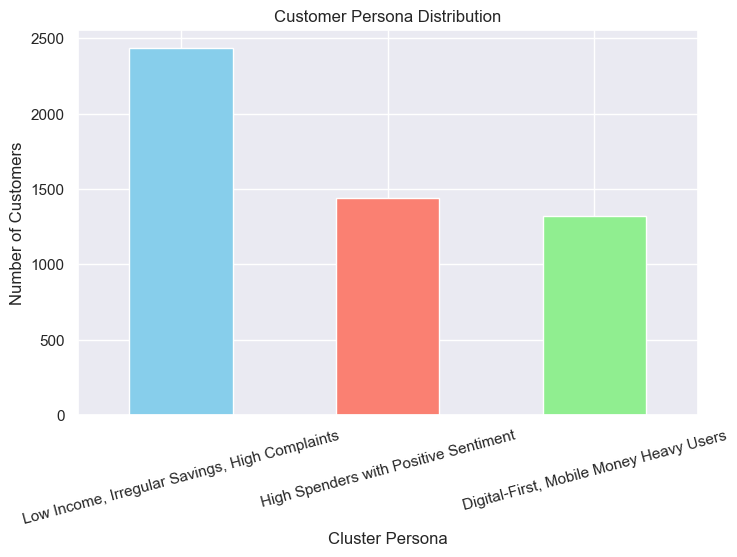

In [53]:
# Compute counts per cluster persona
cluster_counts = X_final["Cluster_Persona"].value_counts()

# Plot bar chart
plt.figure(figsize=(8,5))
cluster_counts.plot(kind="bar", color=["skyblue", "salmon", "lightgreen"])
plt.title("Customer Persona Distribution")
plt.xlabel("Cluster Persona")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

## Conclusion – Cluster Validation & Interpretation

In this stage, we successfully translated **numeric and categorical clustering results** into **meaningful customer personas**.

### Key Customer Personas

- **High Spenders with Positive Sentiment**: Customers with above-average spending and generally positive feedback.  
- **Low Income, Irregular Savings, High Complaints**: Customers with lower income levels, inconsistent savings, and frequent complaints.  
- **Digital-First, Mobile Money Heavy Users**: Customers who primarily use digital channels for transactions and exhibit distinct digital adoption behaviors.

The **visualization of cluster counts** confirmed the relative size of each persona, providing insights into which customer segments dominate the population.

By combining **cluster centroids, population comparisons, and descriptive labeling**, we can now interpret clusters in a business context, enabling:

- Targeted interventions  
- Personalized marketing strategies  
- Data-driven decision-making  

This closes the **unsupervised modeling and interpretation workflow**, leaving the dataset ready for **downstream applications** such as customer targeting, behavior prediction, or anomaly detection.

In [62]:
X_final.head()

,num_PC1,num_PC2,nlp_PC0,nlp_PC1,nlp_PC2,nlp_PC3,nlp_PC4,nlp_PC5,nlp_PC6,nlp_PC7,nlp_PC8,nlp_PC9,Income_Level_Low,Income_Level_Lower-Middle,Income_Level_Middle,Income_Level_Upper-Middle,Spending_Category_Entertainment,Spending_Category_Groceries,Spending_Category_Health,Spending_Category_Online Shopping,Spending_Category_Rent,Spending_Category_Savings Deposit,Spending_Category_Transport,Spending_Category_Utilities,Saving_Behavior_Good,Saving_Behavior_Poor,Loan_Status_Default Risk,Loan_Status_No Loan,Complaint_Type_General Feedback,Complaint_Type_Loan Issue,Complaint_Type_No Complaint,Complaint_Type_Technical Issue,Location_Enugu,Location_Ibadan,Location_Kaduna,Location_Kano,Location_Lagos,Location_Port Harcourt,Time_Of_Day_Evening,Time_Of_Day_Morning,Time_Of_Day_Night,Transaction_Channel_POS,Transaction_Channel_USSD,Transaction_Channel_Web,Cluster,Hier_Cluster,GMM_Cluster,DBSCAN_Cluster,Cluster_Persona
0,-0.672610,-0.415267,0.772728,-0.393254,-0.122825,-0.261247,0.036274,-0.328002,0.013210,-0.012027,-0.004565,-0.004161,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,False,True,False,0,0,1,0,"Low Income, Irregular Savings, High Complaints"
1,-2.012464,-0.799694,-0.052705,0.286378,0.991369,-0.139198,-0.015572,0.012037,0.003654,-0.014013,-0.596214,-0.005705,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,False,False,True,0,0,1,1,"Low Income, Irregular Savings, High Complaints"
2,1.471037,0.566017,-0.052705,0.286378,0.991369,-0.139198,-0.015572,0.012037,0.003654,-0.014013,-0.596214,-0.005705,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,False,False,True,1,2,1,1,High Spenders with Positive Sentiment
3,0.510137,-0.536955,0.673423,-0.333023,-0.100050,0.099462,-0.134504,0.877181,-0.025658,0.002145,-0.000492,-0.006841,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,False,True,False,1,0,1,2,High Spenders with Positive Sentiment
4,-0.860893,-0.308829,-0.615534,-0.481897,-0.115768,-0.079218,-0.348677,-0.041929,-0.005789,0.001929,0.003636,0.680202,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,False,False,False,0,0,1,3,"Low Income, Irregular Savings, High Complaints"


In [63]:
X_final = X_final.drop(columns = ["Hier_Cluster" "GMM_Cluster"	"DBSCAN_Cluster"])

KeyError: "['Hier_ClusterGMM_ClusterDBSCAN_Cluster'] not found in axis"

In [ ]:
# Save the fully processed dataframe to CSV for the dashboard
X_final.to_csv("df_final.csv", index=False)

In [57]:
import pickle

# Bundle models and transformers
model_bundle = {
    "scaler": scaler,
    "encoder": encoder,
    "count_vectorizer": CountVectorizer,
    "tfidf_vectorizer": TfidfVectorizer,
    "lda_model": LatentDirichletAllocation,
    "pca_numeric": pca_numeric,
    "pca_nlp": pca_nlp,
    "cluster_model": kmeans
}

# Save to disk
with open("unsupervised_pipeline.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

In [60]:
a= pd.read_csv(r"C:\Users\AKANBI BENJAMIN\df_final.csv")